In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)


CRYPTO_MARKETS = [
    'eth_wbtc_usdc',
    'base_wbtc_usdt', # not ok
    'eth_cbbtc_usdc', 
    'eth_wbtc_usdt', # not ok
    "eth_wsteth_usdt",
    'eth_weth_usdt', # not ok 
    'eth_cbbtc_usdt', # not ok 
    'base_cbbtc_usdc_full',
    # 'base_wbtc_usdc',
    # 'base_wbtc_usdt',
]
PT_MARKETS = [
    "eth_PT-RLP-4SEP2025_usdc", "eth_PT-USD0++-27MAR2025_usdc",
    "eth_PT-USD0++-31OCT2024_usdc", "eth_PT-USDe-25SEP2025_dai",
    "eth_PT-USDe-25SEP2025_usdc", "eth_PT-USDe-25SEP2025_usdt",
    "eth_PT-USDe-27MAR2025_dai", "eth_PT-USDe-27NOV2025_usds",
    "eth_PT-USDe-31JUL2025_dai", "eth_PT-USR-29MAY2025_usdc",
    "eth_PT-csUSDL-31JUL2025_usdc", "eth_PT-lvlUSD-29MAY2025_usdc",
    "eth_PT-mHYPER-20NOV2025_usdc", "eth_PT-reUSD-18DEC2025_usdc",
    "eth_PT-sNUSD-5MAR2026_usdc",
    "eth_PT-sdeUSD-1753142406_usdc", "eth_PT-slvlUSD-25SEP2025_usdc",
    "eth_PT-slvlUSD-29MAY2025_usdc", "eth_PT-stcUSD-23JUL2026_usdc",
    "eth_PT-stcUSD-29JAN2026_usdc", "eth_PT-syrupUSDC-28AUG2025_usdc",
    "eth_PT-syrupUSDC-30OCT2025_usdc", "eth_PT-wstUSR-25SEP2025_usdc",
    "eth_PT-wstUSR-27MAR2025_usdc", "eth_PT-wstUSR-27MAR2025_usr",
    "PT-reUSD-25JUN2026_usdc", "PT-siUSD-26MAR2026_usdc",

    # "eth_PT-reUSD-25JUN2026_usdc", 
]
YB_TOKENS = [
    'eth_usr_usdc', 'eth_wsteth_usdc', 'eth_rlp_usdc',
    'eth_usd0++_usdc', 'eth_fxsave_usdc', 'eth_mapollo_usdc',
    'eth_wsrusd_usdc', 'eth_syrupusdc_pyusd', 'eth_susde_pyusd',
    'eth_stcusd_usdc', 'eth_usde_dai', 'eth_mhyper_usdc', 'eth_syrupusdc_usdc',
    'eth_wstusr_usdc','eth_slvlusd_usdc','eth_csusdl_usdc', 'eth_mF-ONE_usdc', 'eth_reusd_usdc',
    'eth_siusd_usdc', 'eth_sdeusd_usdc'
]


pd.set_option("display.max_columns", 500)
df = pd.concat([
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/crypto_tokens_positions.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/pt_tokens_positions.csv"),
    pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv"),
], ignore_index=True)
df.loc[df['leverage_factor'] == 0, 'leverage_factor'] = 1
df = df[~df['market'].isin(['PT-reUSD-25JUN2026_usdc', 'PT-siUSD-26MAR2026_usdc'])]

mask = df['close_timestamp'].isna()
for market in df[mask]['market'].unique():
    market_max_ts = df[df['market'] == market]['open_timestamp'].max()
    market_max_dt = df[df['market'] == market]['open_datetime'].max()
    df.loc[(df['market'] == market) & mask, 'close_timestamp'] = market_max_ts
    df.loc[(df['market'] == market) & mask, 'close_datetime'] = market_max_dt

# Recalculate time-based fields for those rows
df.loc[mask, 'duration_hours'] = (df.loc[mask, 'close_timestamp'] - df.loc[mask, 'open_timestamp']) / 3600
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']  # assuming first action = open
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours'] / df.loc[mask, 'n_actions_total'].clip(lower=1)
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']  # approximation
df.loc[mask, 'time_to_first_action'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'avg_time_between_actions'] = df.loc[mask, 'duration_hours']
df.loc[mask, 'max_time_between_actions'] = df.loc[mask, 'duration_hours']
df['avg_repay_ratio'] = 1

susp_opens = df.groupby(["user_address", "open_timestamp", "market"])['open_debt'].count()
susp_opens_addresses = susp_opens[susp_opens > 2].reset_index()['user_address'].unique()

print("Before removing susp addrs", len(df))
df = df[~df['user_address'].isin(susp_opens_addresses)]
print("After removing susp addrs", len(df))

# Set closing fields to opening values for these rows
close_fields = ['close_debt', 'close_ltv', 'close_borrow_rate']
for field in close_fields:
    open_field = field.replace('close', 'open')
    df.loc[mask, field] = df.loc[mask, open_field]



clustering_result = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/modelling_datasets/users_clusters_mapping.csv")
df = df.merge(clustering_result[["user_address", "hdbscan_cluster"]], how='left', on='user_address') \
    .rename(columns={"hdbscan_cluster": "cluster"})
df['market_type'] = df.apply(lambda r : "crypto" if r['market'] in CRYPTO_MARKETS else ("yb" if r['market'] in YB_TOKENS else 'pt'), axis=1)
df.head(3)


Before removing susp addrs 109479
After removing susp addrs 97322


,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,position_index,collateral_asset,loan_asset,cluster,market_type
0,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,0,cbbtc,usdc,-1,crypto
1,0xf8b9D83574574A345c32905a2A62D1d84650A0Ae,base_cbbtc_usdc_full,1726217705,2024-09-13 08:55:05,1.0,0.172022,0.041709,1,1.764177e+09,2025-11-26 17:05:11,1.000000,0.172022,0.041709,1.0,0.172022,0,0,False,10544.168333,10544.168333,10544.168333,10544.168333,0,1,False,0,False,NaN,NaN,False,0.000000,0.0,0.000000,NaN,NaN,0.041709,1,cbbtc,usdc,-1,crypto
2,0x9aE9A52Eb952aE82c592e109f04C844B94e9975a,base_cbbtc_usdc_full,1726241775,2024-09-13 15:36:15,150000.0,0.700799,0.041616,1,1.727133e+09,2024-09-23 23:02:29,-8.357457,-0.231041,0.026968,150000.0,0.700799,3,0,True,247.437222,12.058889,98.025000,195.958889,3,1,False,0,False,150000.0,150000.0,False,0.983789,1.0,0.016478,NaN,NaN,0.030925,2,cbbtc,usdc,-1,crypto


### **Spike responders**

In [2]:
cluster = df[df["cluster"] == 3]
cluster.head(3)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,position_index,collateral_asset,loan_asset,cluster,market_type
77386,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,1727918963,2024-10-03 01:29:23,12996.152000,0.823325,0.021190,2,1.744162e+09,2025-04-09 01:34:47,59994.166461,0.666573,0.039497,69499.305000,0.823325,3,4,True,4512.090000,0.203333,751.981111,1547.206667,7,1,True,128,False,0.003596,0.004102,False,0.762598,3.613649e+06,1.124954e+06,0.166597,65.934690,0.070125,51,cbbtc,usdc,3,crypto
77387,0x00e9eaF42eD86610Df9510d123Cf4d7a5D19FAd4,eth_cbbtc_usdc,1727918963,2024-10-03 01:29:23,12996.152000,0.823325,0.021190,2,1.744162e+09,2025-04-09 01:34:47,59994.166461,0.666573,0.039497,69499.305000,0.823325,3,5,True,4512.090000,0.000000,644.584286,1547.206667,8,1,True,128,False,0.003596,0.004102,False,0.762598,3.613649e+06,1.124954e+06,0.166597,65.934690,0.070125,52,cbbtc,usdc,3,crypto
77544,0x38ac78C059314F933DC7Bd348Fc1E7F11c33c002,eth_cbbtc_usdc,1740023747,2025-02-20 03:55:47,8192.385548,0.819027,0.062451,1,1.768678e+09,2026-01-17 19:19:59,8192.385548,0.819027,0.062451,8192.385548,0.859578,0,1,False,7959.403333,7959.403333,7959.403333,7959.403333,1,1,True,6,False,0.000642,0.000642,False,0.869187,1.276320e+07,1.920868e+06,0.074781,42.346992,0.059001,209,cbbtc,usdc,3,crypto


In [46]:
spikes_data = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/all_spikes_dataset_new.csv")
spikes_data = spikes_data.rename(columns={"market_name": "market"})
print(len(spikes_data))
spikes_data.head(5)

9254


,market,market_address,max_total_supply,market_total_events,market_n_users,market_n_spikes,spike_index,spike_trigger_datetime,spike_recovery_datetime,spike_duration_seconds,spike_magnitude_util_delta,peak_utilization,trigger_event_types,total_borrow_before,total_supply_before,utilization_before,collateral_price,loan_asset_price,debt_before,supply_before,n_total_events_in_spike,n_repay_events_in_spike
0,eth_usr_usdc,0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9...,1.337375e+08,24794,1962,374,0,2025-01-08 01:58:11,2025-01-08 01:59:35,84,0.057467,0.969926,MarketBorrow,2.535919e+06,2.890132e+06,0.877441,1.002000,1.001000,672621.609141,0.000000e+00,4,0
1,eth_usr_usdc,0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9...,1.337375e+08,24794,1962,374,1,2025-01-08 02:00:59,2025-01-08 03:21:35,4836,0.033739,1.000000,MarketWithdraw,2.705706e+06,2.890133e+06,0.936187,1.002000,1.001000,0.000000,1.518041e+06,28,0
2,eth_usr_usdc,0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9...,1.337375e+08,24794,1962,374,2,2025-01-08 03:22:23,2025-01-08 04:05:59,2616,0.034407,1.000000,MarketBorrow,2.803336e+06,2.906347e+06,0.964557,0.998893,0.999622,850224.008720,0.000000e+00,11,0
3,eth_usr_usdc,0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9...,1.337375e+08,24794,1962,374,3,2025-01-08 04:46:23,2025-01-08 05:55:47,4164,0.047492,0.999996,MarketWithdraw,3.102852e+06,3.266722e+06,0.949837,1.000000,1.000000,0.000000,1.892888e+06,19,0
4,eth_usr_usdc,0x8e7cc042d739a365c43d0a52d5f24160fa7ae9b7e7c9...,1.337375e+08,24794,1962,374,4,2025-01-08 06:46:59,2025-01-08 06:51:11,252,0.072097,0.999988,MarketWithdraw,3.399432e+06,3.669362e+06,0.926437,0.998884,0.998514,0.000000,2.291929e+06,3,0


In [30]:
cluster['market'].value_counts()
present_markets = cluster['market'].value_counts().index[:2]
present_markets

Index(['eth_usr_usdc', 'eth_slvlusd_usdc'], dtype='object', name='market')

In [35]:
m = present_markets[1]
df_actions = pd.read_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/" + m + ".csv")
users = cluster[cluster['market'] == m]['user_address'].unique()
df_actions = df_actions[df_actions['user_address'].isin(users)]
print(df_actions['market'].unique())
df_actions.shape

['eth_slvlusd_usdc']


(278, 47)

In [42]:
df_actions.head()

,hash,type,timestamp,user_address,assets,assets_usd,liquidated_assets,liquidated_assets_usd,market,datetime,market_address,total_supply_before,total_borrow_before,total_supply_after,total_borrow_after,utilization_before,utilization_after,tx_actions,borrow_rate_before,supply_rate_before,borrow_rate_after,supply_rate_after,collateral_price,loan_asset_price,collateral_before,collateral_value_before,debt_before,supply_before,ltv_before,collateral_after,collateral_value_after,debt_after,supply_after,ltv_after,health_factor_before,health_factor_after,event_type,vault_flg,volatility_6h,drawdown_6h,trend_6h,volatility_24h,drawdown_24h,trend_24h,event_sequence_type,collateral_asset_symbol,loan_asset_symbol
205,0x423bd3581a3ff750aa9e9f1bf88798fb85ec9b654703...,MarketBorrow,1745494655,0xEf355Ec82Cc3f6ECa99E1116ef160F987641BA6b,1218550000,1218.430582,0,0,eth_slvlusd_usdc,2025-04-24 11:37:35,0x8b1bc4d682b04a16309a8adf77b35de0c42063a79440...,3.087997e+06,2.689682e+06,3.088018e+06,2.690922e+06,0.871012,0.871407,2,0.063535,0.055341,0.063557,0.055385,1.064,0.999939,0.0,0.0,0.0,0.0,0.0,1393.739087,1482.938388,1218.475668,0.0,0.821713,0.0,1.113663,position_open,False,0.000376,-0.00094,0.000941,0.000549,-0.00188,0.001883,position_open,slvlUSD,USDC
206,0x423bd3581a3ff750aa9e9f1bf88798fb85ec9b654703...,MarketSupplyCollateral,1745494655,0xEf355Ec82Cc3f6ECa99E1116ef160F987641BA6b,1393739086753852998525,1482.938388,0,0,eth_slvlusd_usdc,2025-04-24 11:37:35,0x8b1bc4d682b04a16309a8adf77b35de0c42063a79440...,3.087997e+06,2.689682e+06,3.088018e+06,2.690922e+06,0.871012,0.871407,2,0.063535,0.055341,0.063557,0.055385,1.064,0.999939,0.0,0.0,0.0,0.0,0.0,1393.739087,1482.938388,1218.475668,0.0,0.821713,0.0,1.113663,position_open,False,0.000376,-0.00094,0.000941,0.000549,-0.00188,0.001883,position_open,slvlUSD,USDC
288,0x2534927617876aedf72121b58b27aa70d4623f3e165f...,MarketBorrow,1745923451,0xc0BDD078d504cFde3E7999A5f6aF2eB7942e9dac,25395801574,25392.754078,0,0,eth_slvlusd_usdc,2025-04-29 10:44:11,0x8b1bc4d682b04a16309a8adf77b35de0c42063a79440...,1.744594e+06,1.531074e+06,1.744596e+06,1.556472e+06,0.877611,0.892168,2,0.063961,0.056134,0.064751,0.057770,1.065,0.999959,0.0,0.0,0.0,0.0,0.0,26706.391141,28442.306565,25394.760346,0.0,0.892888,0.0,1.024848,position_open,False,0.000375,0.00000,-0.000938,0.000436,0.00000,-0.000938,position_open,slvlUSD,USDC
289,0x2534927617876aedf72121b58b27aa70d4623f3e165f...,MarketSupplyCollateral,1745923451,0xc0BDD078d504cFde3E7999A5f6aF2eB7942e9dac,26706391140563026469823,28442.306565,0,0,eth_slvlusd_usdc,2025-04-29 10:44:11,0x8b1bc4d682b04a16309a8adf77b35de0c42063a79440...,1.744594e+06,1.531074e+06,1.744596e+06,1.556472e+06,0.877611,0.892168,2,0.063961,0.056134,0.064751,0.057770,1.065,0.999959,0.0,0.0,0.0,0.0,0.0,26706.391141,28442.306565,25394.760346,0.0,0.892888,0.0,1.024848,position_open,False,0.000375,0.00000,-0.000938,0.000436,0.00000,-0.000938,position_open,slvlUSD,USDC
290,0xdae8bf75a822b708eecd52ca731109ab3d2965a656c9...,MarketBorrow,1745924147,0x4F9AC3CDC7E46D6cc9B2f94Ef4f26680bF52C023,2518528424,2518.226201,0,0,eth_slvlusd_usdc,2025-04-29 10:55:47,0x8b1bc4d682b04a16309a8adf77b35de0c42063a79440...,1.744596e+06,1.556472e+06,1.744598e+06,1.558993e+06,0.892168,0.893612,2,0.064751,0.057770,0.064830,0.057934,1.065,0.999959,0.0,0.0,0.0,0.0,0.0,2658.087875,2830.863587,2518.425164,0.0,0.889668,0.0,1.028558,position_open,False,0.000375,0.00000,-0.000938,0.000436,0.00000,-0.000938,position_open,slvlUSD,USDC


In [41]:
repays = df_actions[df_actions['type'] == 'MarketRepay']
repays['repay_volume'] = repays['debt_before'] - repays['debt_after']
repays['repay_pct'] = (repays['repay_volume'] / repays['debt_before']).clip(0,1)
repays['util_diff'] = (repays['utilization_after'] - repays['utilization_before'])
repays['total_borrow_impact'] = (repays['repay_volume'] / repays['total_borrow_before'])*100

repays = repays[repays['utilization_before'] >= 0.9]
repaid_users = repays['user_address'].unique()

# df_actions[df_actions['user_address'].isin(repaid_users)][[
repays[[
    "datetime",
    "user_address",
    "type",
    'debt_before',
    'debt_after',
    "repay_volume",
    "repay_pct",
    'utilization_before',
    'utilization_after',
    "util_diff",
    "total_borrow_impact"
]].sort_values("repay_volume", ascending=False).head(50)

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_20293/225211569.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  repays['repay_volume'] = repays['debt_before'] - repays['debt_after']
/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_20293/225211569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  repays['repay_pct'] = (repays['repay_volume'] / repays['debt_before']).clip(0,1)
/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_20293/225211569.py:4: SettingWithCopyWarning: 
A

,datetime,user_address,type,debt_before,debt_after,repay_volume,repay_pct,utilization_before,utilization_after,util_diff,total_borrow_impact
1942,2025-05-25 07:31:59,0x14d5B268a60b67Ace1dB4956cfAB6f046723b1dC,MarketRepay,216089.140210,-519.279587,216608.419797,1.000000,0.923766,0.907977,-0.015789,1.708832
10353,2025-09-01 13:48:35,0xcfDb0cEDEC9a1082Ae9d85AD25f816e13607872a,MarketRepay,199790.028926,-4857.588533,204647.617459,1.000000,0.919051,0.892729,-0.026322,2.864122
10177,2025-08-29 13:35:35,0x049C58135deA6707f8508Af8Ba01d244Eb6e4d44,MarketRepay,199781.442951,-4293.682314,204075.125264,1.000000,0.902873,0.877781,-0.025093,2.778710
1815,2025-05-23 16:00:11,0xdA7A8390DFC4Af5F30B988faF54b996766206725,MarketRepay,181049.613361,-571.253157,181620.866517,1.000000,0.927423,0.914541,-0.012882,1.388754
2952,2025-06-06 09:46:35,0xAD9f225D034A6f5Aa8ED0736590076bfBA9f7B02,MarketRepay,173351.511261,-601.370445,173952.881706,1.000000,0.912713,0.905973,-0.006740,0.738327
5566,2025-07-03 12:20:35,0x863F26238DC5EE599EDFaf4c2333E27f3d64081b,MarketRepay,148286.908560,-1445.058814,149731.967374,1.000000,0.900016,0.895709,-0.004307,0.478463
7043,2025-07-25 05:32:23,0xF7576b2E164e6244Ea54e7085DaCCC328C042774,MarketRepay,144032.575448,-1454.362282,145486.937730,1.000000,0.900396,0.887759,-0.012637,1.403323
6730,2025-07-21 10:02:35,0xB816797F83C6686B8fbA09A7F01046942a4a1956,MarketRepay,138834.571003,-2815.572735,141650.143738,1.000000,0.901387,0.887996,-0.013390,1.485377
6725,2025-07-21 09:44:35,0xB816797F83C6686B8fbA09A7F01046942a4a1956,MarketRepay,275366.373948,138834.571003,136531.802945,0.495819,0.900301,0.491039,-0.409262,1.411495
3548,2025-06-12 04:52:47,0x77b4BBB10F574C744541F69c9aD85c7Fa17D478E,MarketRepay,115728.227106,-48.389138,115776.616244,1.000000,0.930355,0.927148,-0.003207,0.344669


In [68]:
import os
def load_market_actions(market, actions_dir):
    file_path = os.path.join(actions_dir, f"{market}.csv")
    return pd.read_csv(file_path)

def filter_actions_by_users(actions_df, users):
    return actions_df[actions_df['user_address'].isin(users)].copy()

def process_repays(actions_df):
    repays = actions_df[actions_df['type'] == 'MarketRepay'].copy()
    repays['repay_volume'] = repays['debt_before'] - repays['debt_after']
    repays['repay_pct'] = (repays['repay_volume'] / repays['debt_before']).clip(0, 1)
    repays['util_diff'] = repays['utilization_after'] - repays['utilization_before']
    repays['total_borrow_impact'] = (repays['repay_volume'] / repays['total_borrow_before']) * 100
    return repays

def filter_high_util_repays(repays_df, threshold=0.9):
    return repays_df[repays_df['utilization_before'] >= threshold].copy()

def merge_repays_with_spikes(repays_df, spike_df):
    repays = repays_df.reset_index(drop=True).reset_index()
    spike = spike_df.copy()
    spike['spike_start_unix'] = pd.to_datetime(spike['spike_trigger_datetime']).astype(np.int64) // 10**9
    spike['spike_end_unix'] = pd.to_datetime(spike['spike_recovery_datetime']).astype(np.int64) // 10**9

    
    merged = pd.merge(repays, spike[['market', 'spike_start_unix', 'spike_end_unix']], on='market', how='inner')
    mask = (merged['timestamp'] >= merged['spike_start_unix']) & (merged['timestamp'] <= merged['spike_end_unix'])
    merged = merged[mask].copy()
    merged['time_from_spike_start_hours'] = (merged['timestamp'] - merged['spike_start_unix']) / 3600
    merged = merged.drop_duplicates(subset='index', keep='first')
    return merged.drop(columns=['index'])

def compute_market_metrics(repays_df):
    q_list = [0.75, 0.9]
    metrics = {}
    metrics['count'] = len(repays_df)
    metrics['sum_repay_volume'] = repays_df['repay_volume'].sum()
    for q in q_list:
        metrics[f'repay_volume_q{int(q*100)}'] = repays_df['repay_volume'].quantile(q)
        metrics[f'repay_pct_q{int(q*100)}'] = repays_df['repay_pct'].quantile(q)
        metrics[f'total_borrow_impact_q{int(q*100)}'] = repays_df['total_borrow_impact'].quantile(q)
        metrics[f'time_from_spike_start_hours_q{int(q*100)}'] = repays_df['time_from_spike_start_hours'].quantile(q)
    
    metrics[f'repay_volume_median'] = repays_df['repay_volume'].median()
    metrics[f'repay_pct_median'] = repays_df['repay_pct'].median()
    metrics[f'total_borrow_impact_median'] = repays_df['total_borrow_impact'].median()
    metrics[f'time_from_spike_start_hours_median'] = repays_df['time_from_spike_start_hours'].median()
    return metrics

def display_market_metrics(market, metrics_dict):
    print(f"\nMetrics for market: {market}")
    print("-" * 50)
    df_metrics = pd.DataFrame([metrics_dict])
    print(df_metrics.to_string(index=False))

def analyze_spike_repays(cluster_df, spike_df, actions_dir, n_markets=2, util_threshold=0.9):
    top_markets = cluster_df['market'].value_counts().index[:n_markets]
    all_metrics = {}

    for market in top_markets:
        actions_df = load_market_actions(market, actions_dir)
        market_users = cluster_df[cluster_df['market'] == market]['user_address'].unique()
        actions_filtered = filter_actions_by_users(actions_df, market_users)
        repays = process_repays(actions_filtered)
        repays_high_util = filter_high_util_repays(repays, threshold=util_threshold)
        repays_with_spike = merge_repays_with_spikes(repays_high_util, spike_df)
        market_metrics = compute_market_metrics(repays_with_spike)
        all_metrics[market] = market_metrics
        display_market_metrics(market, market_metrics)

    return all_metrics


all_metrics = analyze_spike_repays(
    cluster,
    spikes_data,
    "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/markets_enriched/",
    n_markets=50,
)


Metrics for market: eth_usr_usdc
--------------------------------------------------
 count  sum_repay_volume  repay_volume_q75  repay_pct_q75  total_borrow_impact_q75  time_from_spike_start_hours_q75  repay_volume_q90  repay_pct_q90  total_borrow_impact_q90  time_from_spike_start_hours_q90  repay_volume_median  repay_pct_median  total_borrow_impact_median  time_from_spike_start_hours_median
    19      1.567909e+06     136250.887883       0.976953                 0.290306                         0.918333     170839.638809            1.0                 0.492399                         1.400667         99995.800008          0.540848                    0.122441                            0.846667

Metrics for market: eth_slvlusd_usdc
--------------------------------------------------
 count  sum_repay_volume  repay_volume_q75  repay_pct_q75  total_borrow_impact_q75  time_from_spike_start_hours_q75  repay_volume_q90  repay_pct_q90  total_borrow_impact_q90  time_from_spike_start_hours_q90

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_20293/3434063002.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path)



Metrics for market: eth_rlp_usdc
--------------------------------------------------
 count  sum_repay_volume  repay_volume_q75  repay_pct_q75  total_borrow_impact_q75  time_from_spike_start_hours_q75  repay_volume_q90  repay_pct_q90  total_borrow_impact_q90  time_from_spike_start_hours_q90  repay_volume_median  repay_pct_median  total_borrow_impact_median  time_from_spike_start_hours_median
     0               0.0               NaN            NaN                      NaN                              NaN               NaN            NaN                      NaN                              NaN                  NaN               NaN                         NaN                                 NaN

Metrics for market: eth_mhyper_usdc
--------------------------------------------------
 count  sum_repay_volume  repay_volume_q75  repay_pct_q75  total_borrow_impact_q75  time_from_spike_start_hours_q75  repay_volume_q90  repay_pct_q90  total_borrow_impact_q90  time_from_spike_start_hours_q90 

In [57]:
all_metrics

{'eth_usr_usdc': {'count': 19,
  'sum_repay_volume': 1567909.08464609,
  'repay_volume_q75': 136250.8878830464,
  'repay_pct_q75': 0.9769528181450291,
  'total_borrow_impact_q75': 0.2903058934272599,
  'time_from_spike_start_hours_q75': 0.9183333333333333,
  'repay_volume_q90': 170839.638809239,
  'repay_pct_q90': 1.0,
  'total_borrow_impact_q90': 0.49239878321774744,
  'time_from_spike_start_hours_q90': 1.400666666666666},
 'eth_slvlusd_usdc': {'count': 2,
  'sum_repay_volume': 33274.22979574626,
  'repay_volume_q75': 18103.031934844545,
  'repay_pct_q75': 0.7792538308017293,
  'total_borrow_impact_q75': 0.08121231518048454,
  'time_from_spike_start_hours_q75': 0.28583333333333333,
  'repay_volume_q90': 18982.582157027395,
  'repay_pct_q90': 0.9117015323206917,
  'total_borrow_impact_q90': 0.08582671656124359,
  'time_from_spike_start_hours_q90': 0.30633333333333335},
 'eth_PT-csUSDL-31JUL2025_usdc': {'count': 3,
  'sum_repay_volume': 123750.13189167721,
  'repay_volume_q75': 61040.54

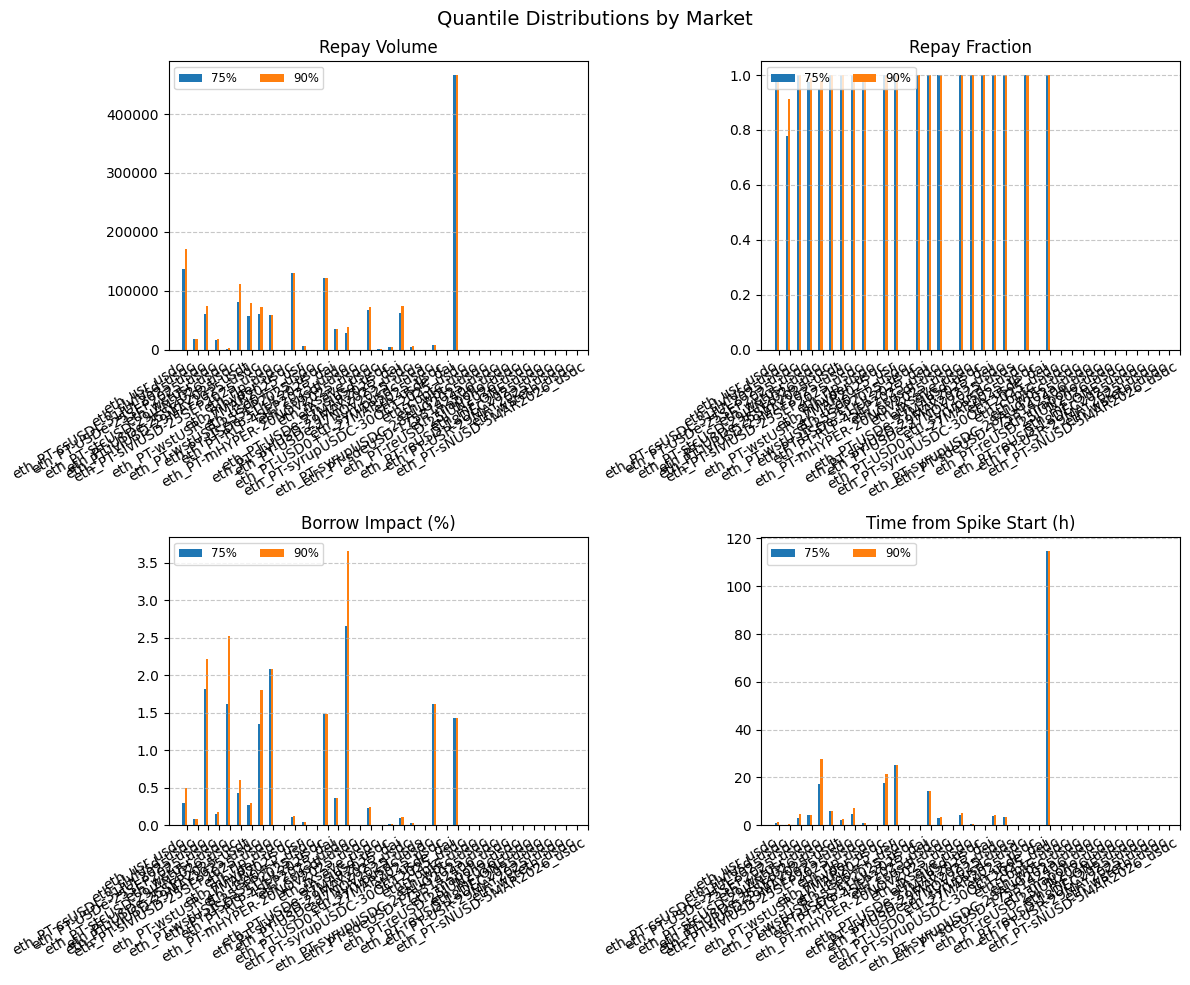

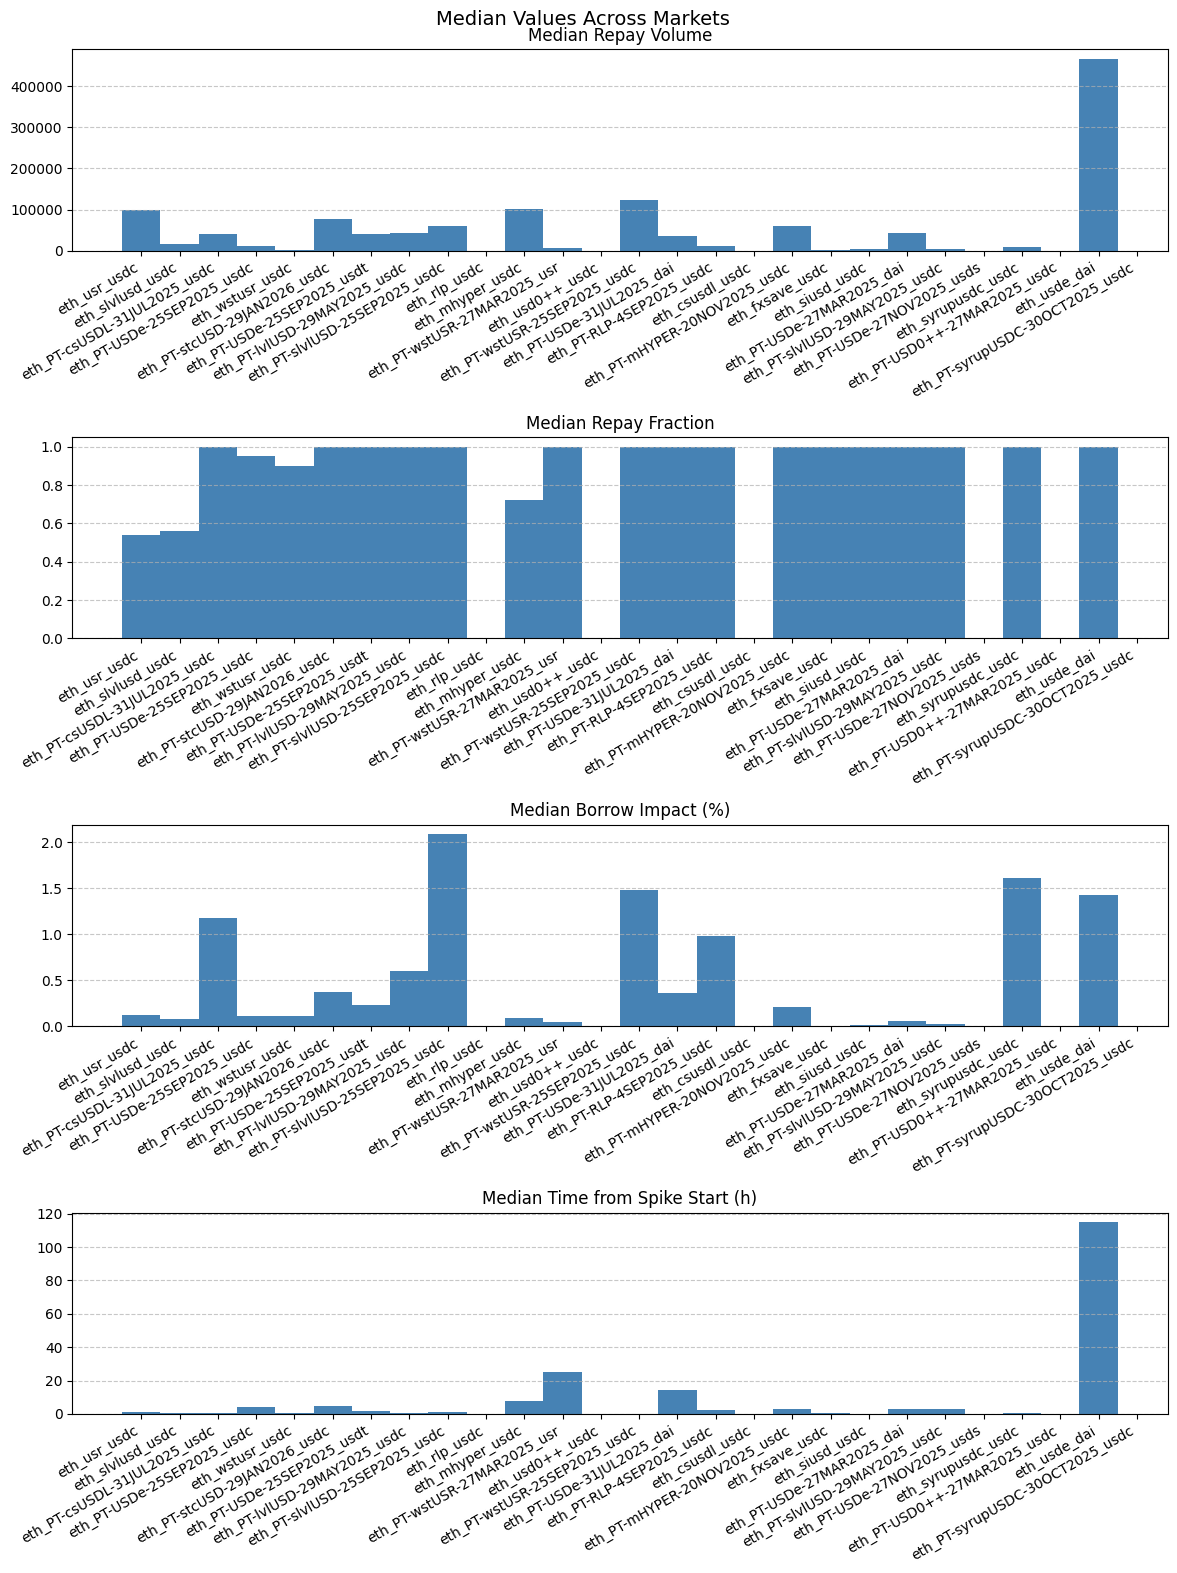

                         market  n_repays  total_repay_volume
                   eth_usr_usdc        19        1.567909e+06
               eth_slvlusd_usdc         2        3.327423e+04
   eth_PT-csUSDL-31JUL2025_usdc         3        1.237501e+05
     eth_PT-USDe-25SEP2025_usdc         2        2.256160e+04
                eth_wstusr_usdc         3        4.115838e+03
   eth_PT-stcUSD-29JAN2026_usdc         5        3.631770e+05
     eth_PT-USDe-25SEP2025_usdt         4        1.762123e+05
   eth_PT-lvlUSD-29MAY2025_usdc         3        1.436220e+05
  eth_PT-slvlUSD-25SEP2025_usdc         1        5.936121e+04
                   eth_rlp_usdc         0        0.000000e+00
                eth_mhyper_usdc         5        5.045503e+05
    eth_PT-wstUSR-27MAR2025_usr         1        5.810937e+03
                eth_usd0++_usdc         0        0.000000e+00
   eth_PT-wstUSR-25SEP2025_usdc         1        1.225270e+05
      eth_PT-USDe-31JUL2025_dai         1        3.513775e+04
       e

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
def visualize_metrics(all_metrics):
    markets = list(all_metrics.keys())
    metric_cats = [
        ('repay_volume', 'Repay Volume'),
        ('repay_pct', 'Repay Fraction'),
        ('total_borrow_impact', 'Borrow Impact (%)'),
        ('time_from_spike_start_hours', 'Time from Spike Start (h)')
    ]
    q_labels = ['75%', '90%']
    q_keys = [75, 90]

    fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
    axes1 = axes1.flatten()
    for ax, (metric, title) in zip(axes1, metric_cats):
        data_matrix = np.zeros((len(markets), len(q_keys)))
        for i, market in enumerate(markets):
            for j, q in enumerate(q_keys):
                data_matrix[i, j] = all_metrics[market][f'{metric}_q{q}']
        x = np.arange(len(markets))
        width = 0.2
        for j in range(len(q_keys)):
            ax.bar(x + j*width, data_matrix[:, j], width, label=q_labels[j])
        ax.set_title(title)
        ax.set_xticks(x + 1.5*width)
        ax.set_xticklabels(markets, rotation=30, ha='right')
        ax.legend(loc='upper left', fontsize='small', ncol=2)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig1.suptitle('Quantile Distributions by Market', fontsize=14)
    plt.tight_layout()

    fig2, axes2 = plt.subplots(4, 1, figsize=(12, 16))
    for ax, (metric, title) in zip(axes2, metric_cats):
        medians = [all_metrics[m][f'{metric}_median'] for m in markets]
        ax.bar(markets, medians, color='steelblue', width=1.0)
        ax.set_title(f'Median {title}')
        ax.set_xticklabels(markets, rotation=30, ha='right')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig2.suptitle('Median Values Across Markets', fontsize=14)
    plt.tight_layout()
    plt.show()


    counts = [all_metrics[m]['count'] for m in markets]
    total_volumes = [all_metrics[m]['sum_repay_volume'] for m in markets]
    summary_df = pd.DataFrame({'market': markets, 'n_repays': counts, 'total_repay_volume': total_volumes})
    print(summary_df.to_string(index=False))

visualize_metrics(all_metrics)